# Getting and setting up the data for EDA

In [3]:
# Import file upload module from Google Colab
from google.colab import files

# Upload kaggle.json file (contains API credentials)
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"simphiwebusakwe","key":"1c6b0c8cc0112dff45cc2c76e6871b4b"}'}

In [4]:
# Setting up Kaggle API credentials directory
import os

# Create a .kaggle folder in the root directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Copy the uploaded kaggle.json file to the correct location
!cp kaggle.json /root/.kaggle/

# Set correct permissions for security
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
# Download Breast Cancer Wisconsin dataset from Kaggle
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
100% 48.6k/48.6k [00:00<00:00, 47.8MB/s]



In [6]:
# Unzip the downloaded dataset file
!unzip breast-cancer-wisconsin-data.zip

Archive:  breast-cancer-wisconsin-data.zip
  inflating: data.csv                


In [7]:
# Import pandas to work with dataset
import pandas as pd

# Load dataset into DataFrame
df = pd.read_csv('data.csv')

# Display first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# EDA Execution

In [8]:
# Drop unnecessary columns (ID and empty column)
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Convert target variable to numeric
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Check result
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# Display basic information about the dataset
# This includes number of rows, columns, data types, and non-null values
df.info()

# Generate summary statistics for all numerical features
# This shows measures such as mean, standard deviation, minimum and maximum values
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [10]:
# Check for missing values in each column
# This helps identify if any data is incomplete and needs cleaning
df.isnull().sum()


,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


## **Class Distribution (EDA)**

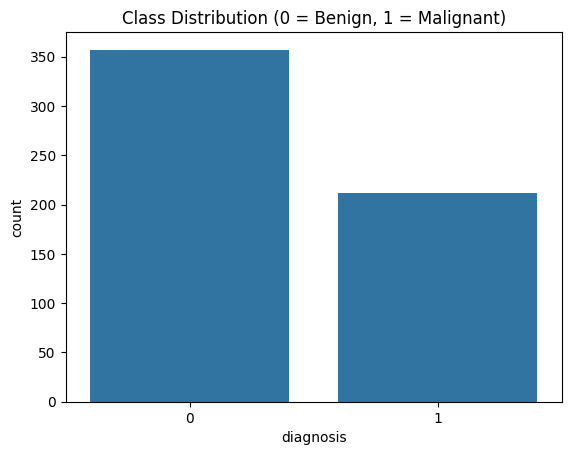

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualise the distribution of the target variable (diagnosis)
# 0 represents benign cases and 1 represents malignant cases
sns.countplot(x='diagnosis', data=df)

# Add a title to the plot for clarity
plt.title("Class Distribution (0 = Benign, 1 = Malignant)")

# Display the plot
plt.show()



The class distribution shows that there are more benign cases (0) than malignant cases (1), indicating a slight class imbalance.

This is important because the model may be biased towards the majority class, so additional evaluation metrics such as precision and recall will be used to ensure balanced performance.


## **Feature** **Distribution (EDA)**

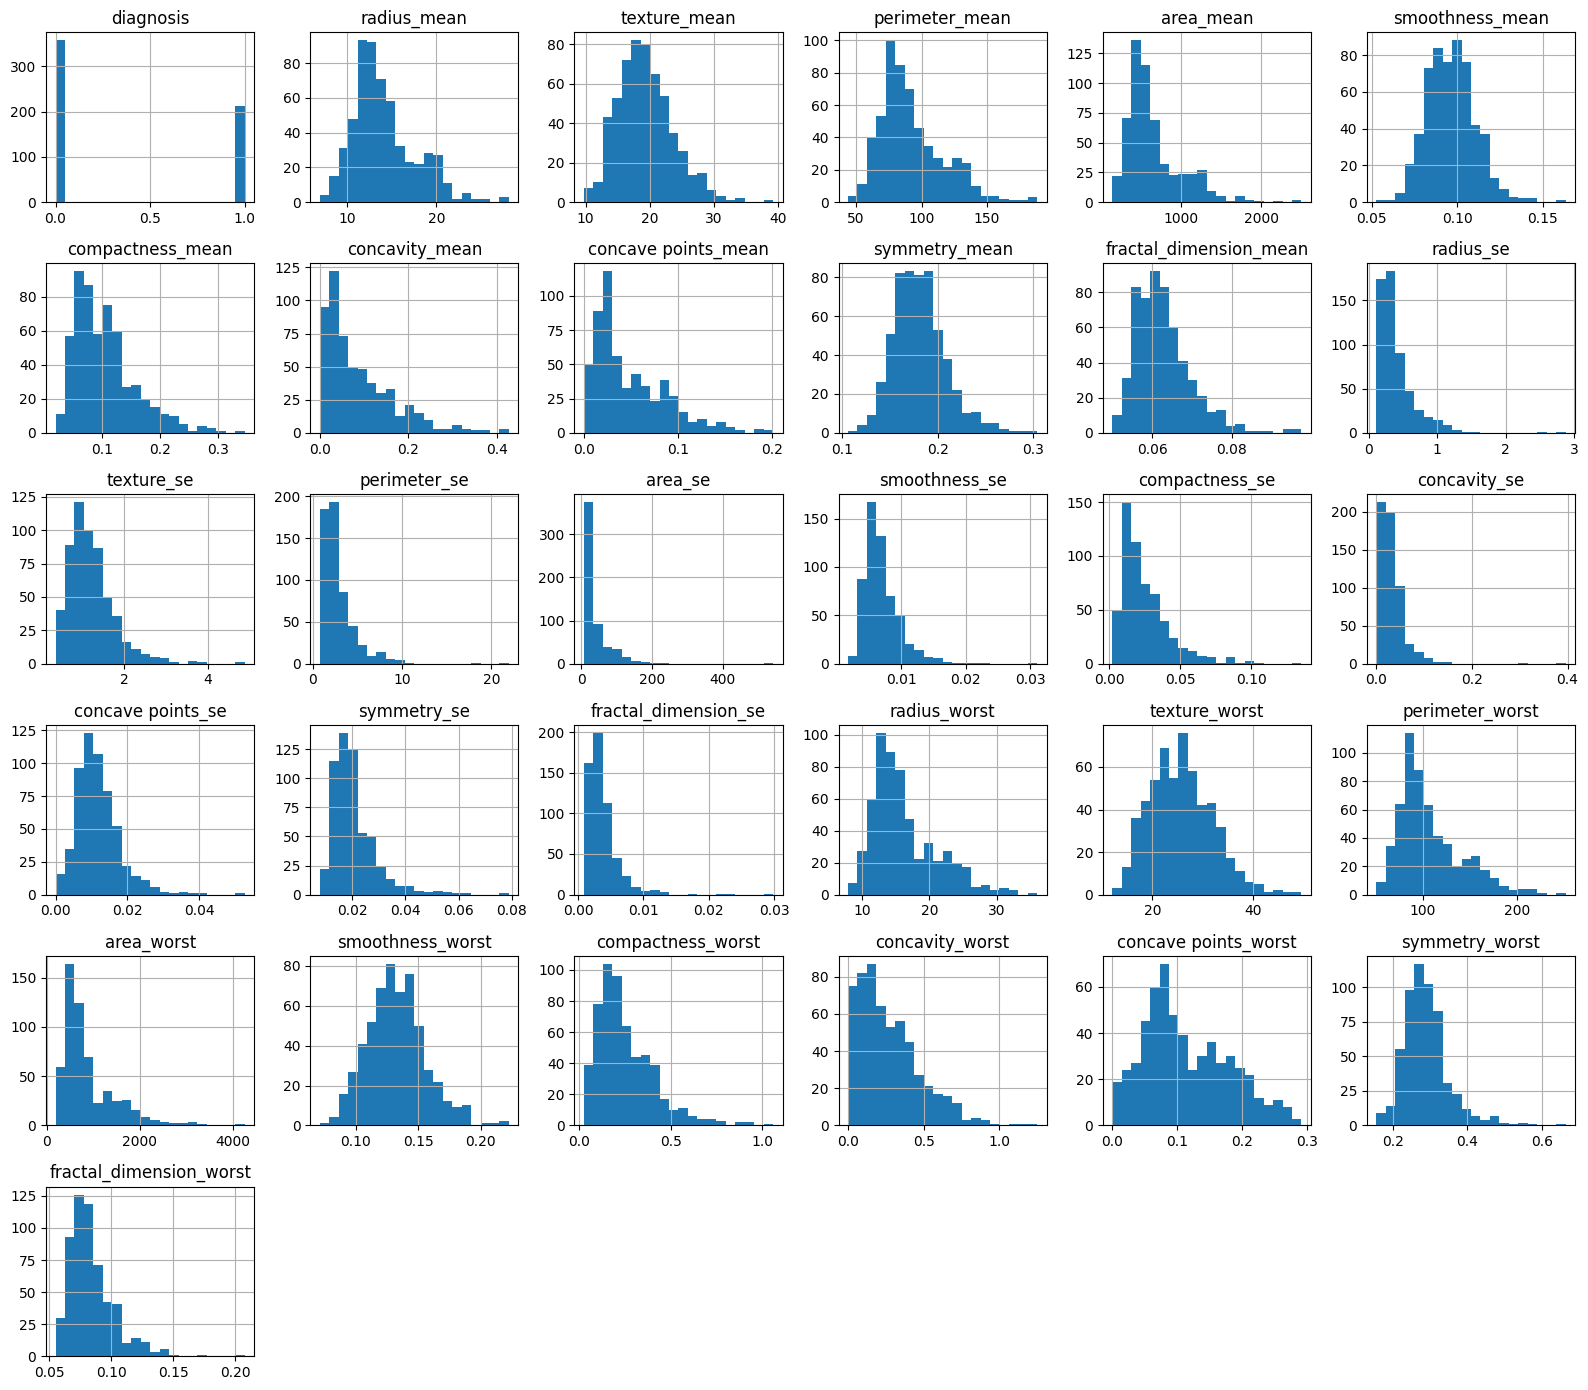

In [24]:
# Ploted all features in a more structured layout
df.hist(bins=20, figsize=(16,14))

plt.tight_layout()
plt.show()



The histograms show the distribution of all numerical features in the dataset. Most features are right-skewed, meaning that values are concentrated at lower ranges with fewer higher values.

Some features also appear approximately normally distributed, while others show strong skewness, indicating variation in how tumour characteristics are measured.

This is important as it shows that the dataset contains diverse feature distributions, which may influence model performance and highlight the presence of outliers.


## **Correlation Analysis (EDA)**

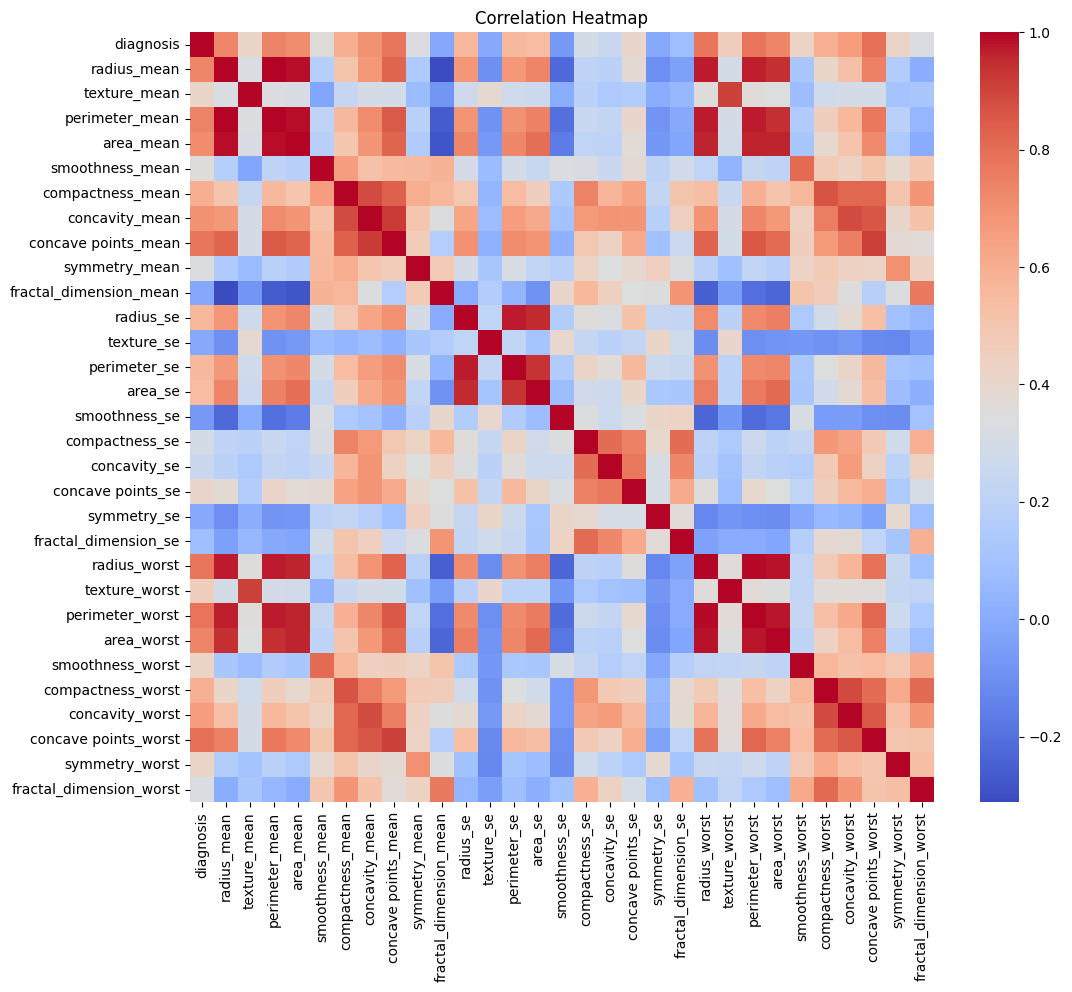

In [20]:
# Create a heatmap to visualise correlations between features
# This helps identify relationships between variables and detect multicollinearity
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')

# Add title for clarity
plt.title("Correlation Heatmap")

# Display the plot
plt.show()


The correlation heatmap shows the relationships between all features in the dataset. Strong positive correlations are visible between features such as radius, perimeter, and area, indicating that these variables are closely related.

Some features also show moderate correlations, while others have weak or negative relationships, suggesting that they capture different aspects of tumour characteristics.

This is important because highly correlated features may introduce redundancy (multicollinearity), which can affect model performance. As a result, feature selection will be applied to retain the most relevant variables.


## **Outlier Detection (EDA)**

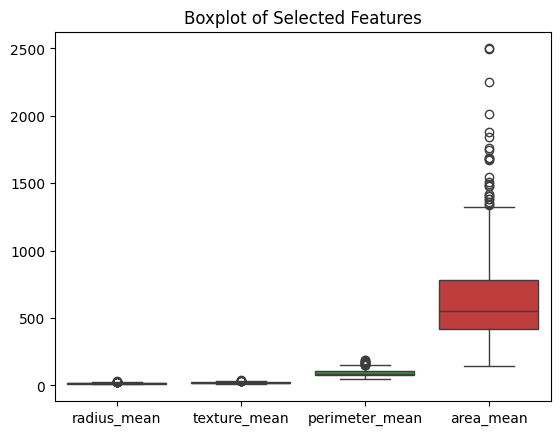

In [13]:
# Create boxplots to detect outliers in selected features
# Boxplots help identify extreme values in the dataset
sns.boxplot(data=df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']])

# Add title
plt.title("Boxplot of Selected Features")

# Show plot
plt.show()


The boxplots show the distribution of selected features and highlight the presence of outliers in the dataset. Several extreme values can be observed, especially in the *area_mean* feature, where values extend far beyond the upper whisker.

This indicates that some tumour measurements are significantly larger than the majority, suggesting variability in the data. These outliers may influence model performance and therefore need to be considered during analysis.

## **Class-Based Boxplot**

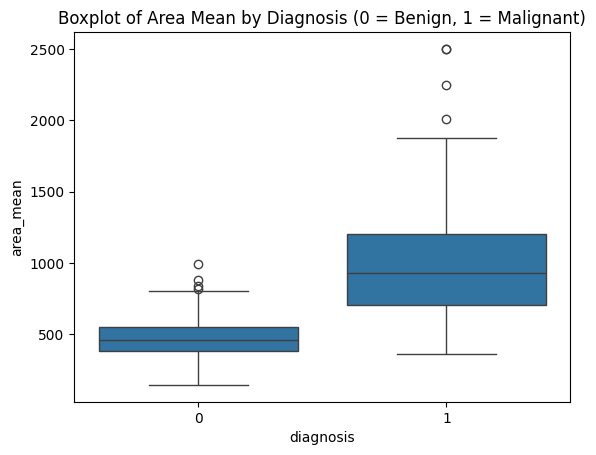

In [14]:
# Boxplot showing feature distribution by class
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='diagnosis', y='area_mean', data=df)

plt.title("Boxplot of Area Mean by Diagnosis (0 = Benign, 1 = Malignant)")
plt.show()

The boxplot compares *area_mean* between benign (0) and malignant (1) cases. Malignant tumours generally have higher values, with a higher median and wider spread.

This indicates that malignant tumours tend to be larger and more variable than benign ones. The clear difference between the two classes suggests that *area_mean* is an important feature for distinguishing between tumour types.

# FEATURE SELECTION

In [15]:
# Separate input features and target variable
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [16]:
# Calculate correlation with target variable
corr_target = df.corr()['diagnosis'].sort_values(ascending=False)

# Display correlations
print(corr_target)


diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

In [17]:
# Select features with strong correlation (example threshold)
selected_features = corr_target[abs(corr_target) > 0.5].index

print("Selected Features:")
print(selected_features)


Selected Features:
Index(['diagnosis', 'concave points_worst', 'perimeter_worst',
       'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst',
       'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst',
       'compactness_mean', 'compactness_worst', 'radius_se', 'perimeter_se',
       'area_se'],
      dtype='object')


In [18]:
# Remove target variable from selected features
selected_features = selected_features.drop('diagnosis')

In [19]:
print(selected_features)


Index(['concave points_worst', 'perimeter_worst', 'concave points_mean',
       'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean',
       'area_mean', 'concavity_mean', 'concavity_worst', 'compactness_mean',
       'compactness_worst', 'radius_se', 'perimeter_se', 'area_se'],
      dtype='object')


# Model Training

In [20]:
from sklearn.model_selection import train_test_split

# Use selected features
X = df[selected_features]
y = df['diagnosis']

# Split dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print(X_train.shape, X_test.shape)

(455, 15) (114, 15)


In [21]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
# Predict on test data
y_pred = rf_model.predict(X_test)

In [23]:
# to see the predictions
print(y_pred[:10])

[0 1 1 0 0 1 1 1 1 0]


In [24]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy of the model
# Accuracy measures the proportion of correct predictions made by the model
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy result
print("Accuracy:", accuracy)



Accuracy: 0.956140350877193


In [26]:
from sklearn.metrics import confusion_matrix, classification_report

# Generate the confusion matrix
# This shows the number of correct and incorrect predictions made by the model
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Generate a detailed classification report
# This includes precision, recall, and F1-score for each class
report = classification_report(y_test, y_pred)
print(report)

[[69  2]
 [ 3 40]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

